In [1]:
import pandas as pd

filename = "../../data/processed/frogID5_database_prepared.csv"
frogID5_database_final = pd.read_csv(filename, sep=',', on_bad_lines='skip')

In [8]:
import datetime

### preparing data
year_month_counts = frogID5_database_final.groupby(['year', 'month']).size().reset_index(name='counts')
year_month_counts['eventMonth'] = year_month_counts['month'].astype(str) + '/' + year_month_counts['year'].astype(str)
year_month_counts['eventMonth'] = pd.to_datetime(year_month_counts['eventMonth'], format='%m/%Y')
year_month_counts = year_month_counts.set_index('eventMonth')[['counts']]

year_month_counts#.head(60)

,counts
eventMonth,
2017-11-01,7416
2017-12-01,5746
2018-01-01,4669
2018-02-01,3750
2018-03-01,2450
...,...
2022-07-01,9211
2022-08-01,16838
2022-09-01,36047


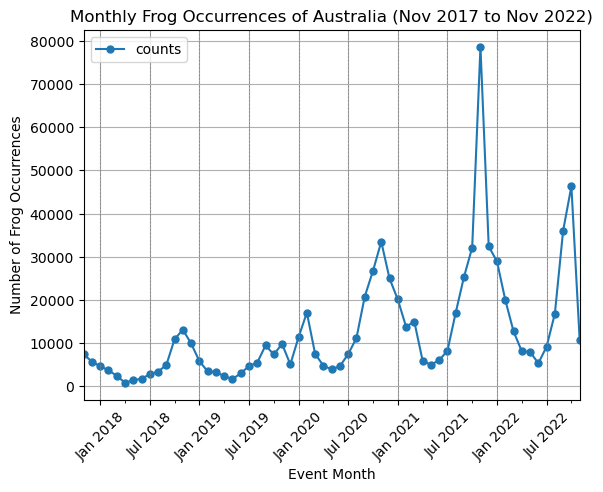

In [15]:
import matplotlib.pyplot as plt

# plotting
monthly_counts_by_state_territory_plot = year_month_counts.plot(marker='o', markersize=5)

# Vertikale Gitterlinien hinzufügen
start_date = year_month_counts.index.min().to_period('M').to_timestamp()
end_date = year_month_counts.index.max().to_period('M').to_timestamp()


monthly_counts_by_state_territory_plot.grid(True)

ticks = []
tick_labels = []
current_date = start_date

while current_date <= end_date:
    if current_date.month == 1 or current_date.month == 7:
        monthly_counts_by_state_territory_plot.axvline(current_date, color='gray', linestyle='--', linewidth=0.5)
        ticks.append(current_date)
        tick_labels.append(current_date.strftime('%b %Y'))
    current_date += pd.DateOffset(months=1)

# Ticks und Labels setzen
monthly_counts_by_state_territory_plot.set_xticks(ticks)
monthly_counts_by_state_territory_plot.set_xticklabels(tick_labels, rotation=45)

# Titel und Achsenbeschriftungen setzen
monthly_counts_by_state_territory_plot.set_title('Monthly Frog Occurrences of Australia (Nov 2017 to Nov 2022)')
monthly_counts_by_state_territory_plot.set_xlabel('Event Month')
monthly_counts_by_state_territory_plot.set_ylabel('Number of Frog Occurrences')

plt.show()